# CAA Project - Deep Learning Approaches for Pneumonia Detection: A Comparative Study on Chest X-Ray Images

**DenseNet-169 Augmented Models Notebook**

**Description:** This is the Jupyter Notebook training and evaluating a DenseNet-169 model on the Pneumonia dataset with data augmentation.

Authors:
- Rafaela Abrunhosa, 107658
- Miguel Pinto, 107449

# External Libraries

In [2]:
# Import utility libraries
import os
import sys
import time
from datetime import datetime
sys.path.append('..')  # Add parent directory to path to allow import of custom modules

# Import deep learning libraries
import tensorflow as tf

# Suppress TensorFlow warnings
import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'    # 0=all, 1=info, 2=warning, 3=error
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'   # Disable oneDNN optimizations for reproducibility

# Disable verbose output from TensorFlow during training
tf_verbosity = 1  # 0 = silent, 1 = progress bar, 2 = one line per epoch

# Import custom utilities
from utils.data_utils import load_and_preprocess_data
from utils.model.densenet_utils import build_densenet169_model
from utils.train_utils import get_callbacks
from utils.eval_utils import evaluate_model
from utils.plot_utils import plot_training_history, plot_roc_curve, plot_confusion_matrix
from utils.logger_utils import ModelLogger

# Core Variables

In [3]:
# Global seed for reproducibility
RANDOM_SEED = 42

# Path variables
DATA_PATH = '../data/'                                          # Path to the dataset
OUTPUT_PATH = '../output/'                                      # Path to save output files
MODEL_PATH = OUTPUT_PATH + 'models/'                            # Path to save the model
MODEL_NAME = 'densenet_169_augmented'                           # Name of the model to be saved
LOG_PATH = OUTPUT_PATH + 'logs/'+ MODEL_NAME + '_info.json'     # Path to save model metrics

# Ensure directories exist
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(LOG_PATH), exist_ok=True)

In [22]:
# Training parameters
EPOCHS = 100                # Number of epochs to train
BATCH_SIZE = 96             # Batch size for training
LEARNING_RATE = 0.001       # Learning rate for the optimizer

# Dropout parameters
DROPOUT_MODE = "fixed"      # Only fixed dropout is supported in this version
DROPOUT_RATE = 0.3          # Fixed dropout rate

# Model selection parameters
CHOSEN_METRIC = 'val_AUC'   # Metric to be used for model selection
MODE = 'max'                # Whether to maximize or minimize the chosen metric

# Final model path
FINAL_MODEL_PATH = f'{MODEL_PATH}{MODEL_NAME}_b{BATCH_SIZE}_lr{LEARNING_RATE}_dr{DROPOUT_RATE}_pneumonia_model.keras'

# Create model logger
logger = ModelLogger()

# Data Loading & Preprocessing

In [23]:
train_dataset, (test_images, test_labels), (val_images, val_labels) = load_and_preprocess_data(
        DATA_PATH,
        augment=True,
        batch_size=BATCH_SIZE,
        seed=RANDOM_SEED
    )


Dataset shapes - Original:
Train - images: (4708, 28, 28)  labels: (4708, 1)
Val   - images: (524, 28, 28)  labels: (524, 1)
Test  - images: (624, 28, 28)  labels: (624, 1)

Dataset shapes - After preprocessing:
Train images shape: (4708, 28, 28, 1)
Train labels shape: (4708, 2)
Val images shape: (524, 28, 28, 1)
Val labels shape: (524, 2)
Test images shape: (624, 28, 28, 1)
Test labels shape: (624, 2)

Applying data augmentation to training data...


# DenseNet-169 Model

## Creation & Compilation

In [24]:
# Initialize model info for logging
model_info = {
    "model_name": MODEL_NAME,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "dropout_mode": DROPOUT_MODE,
    "dropout_rate": DROPOUT_RATE if DROPOUT_MODE == "fixed" else None,
    "dropout_start": None,
    "dropout_end": None,
    "random_seed": RANDOM_SEED
}

# Initialize logger with model info
logger.initialize_run(model_info)

In [25]:
# Create and compile model
model = build_densenet169_model(dropout_rate=DROPOUT_RATE)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 3)      │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_2 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet169 (Functional)        │ (None, 7, 7, 1664)     │    12,642,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1664)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1664)           │         6,656 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       852,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc (Dense)                      │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,505,096 (51.52 MB)

 Trainable params: 857,864 (3.27 MB)

 Non-trainable params: 12,647,232 (48.25 MB)

## Training

In [26]:
# Get callbacks
callbacks = get_callbacks(FINAL_MODEL_PATH, monitor=CHOSEN_METRIC, mode=MODE)

In [27]:
# Train model
start_time = time.time()

history = model.fit(
        train_dataset,
        validation_data=(val_images, val_labels),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=tf_verbosity
    )

exec_time = round(time.time() - start_time, 2)
print(f"Model training completed in {exec_time} seconds")

# Save training info to logger
logger.add_training_info(history, exec_time)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - AUC: 0.9010 - accuracy: 0.8395 - loss: 0.4744 - val_AUC: 0.9511 - val_accuracy: 0.9008 - val_loss: 0.3075 - learning_rate: 0.0010
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 76s 615ms/step - AUC: 0.9667 - accuracy: 0.9330 - loss: 0.2438 - val_AUC: 0.9649 - val_accuracy: 0.9218 - val_loss: 0.2639 - learning_rate: 0.0010
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 621ms/step - AUC: 0.9815 - accuracy: 0.9423 - loss: 0.1767 - val_AUC: 0.9713 - val_accuracy: 0.9237 - val_loss: 0.2251 - learning_rate: 0.0010
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 599ms/step - AUC: 0.9748 - accuracy: 0.9351 - loss: 0.1977 - val_AUC: 0.9696 - val_accuracy: 0.9179 - val_loss: 0.2167 - learning_rate: 0.0010
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 652ms/step - AUC: 0.9819 - accuracy: 0.9455 - loss: 0.1548 - val_AUC: 0.9726 - val_accuracy: 0.9198 - val_loss: 0.2082 - learning_rate: 0.0010
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 38s 587ms/step - AUC: 0.9855 - ac

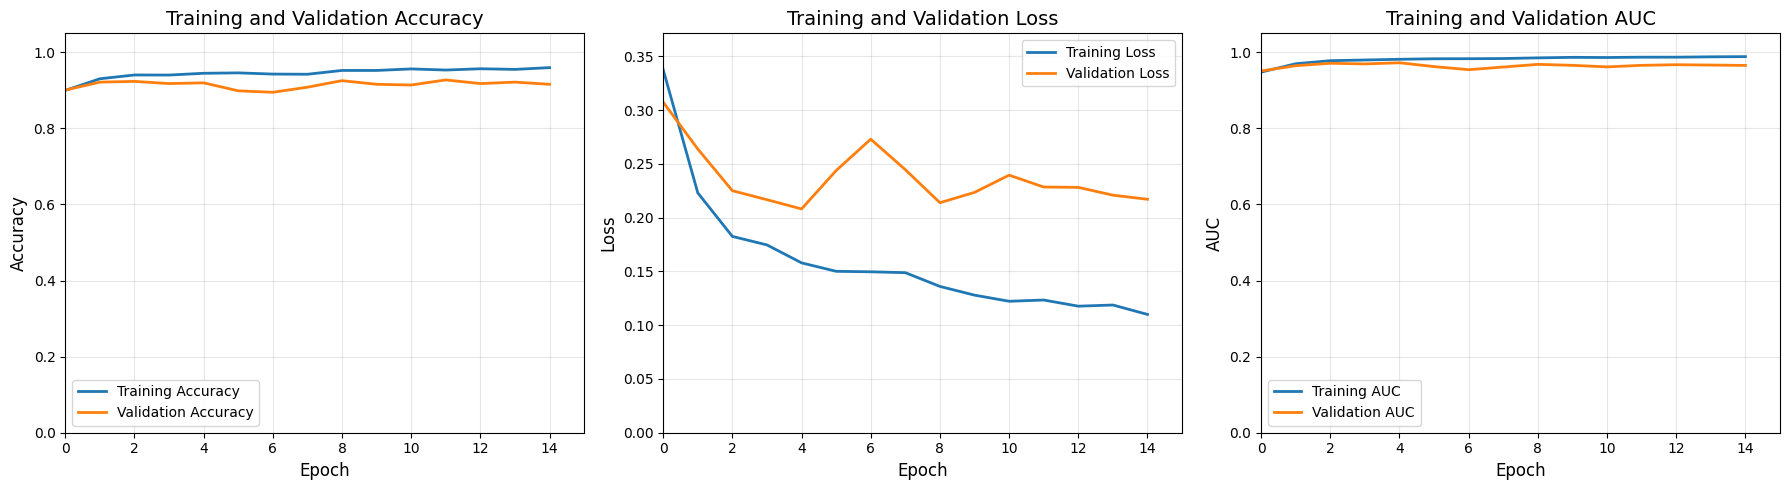

In [28]:
# Plot training history
plot_training_history(history)

## Evaluation

20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 581ms/step - AUC: 0.9189 - accuracy: 0.8425 - loss: 0.3808
20/20 ━━━━━━━━━━━━━━━━━━━━ 33s 926ms/step


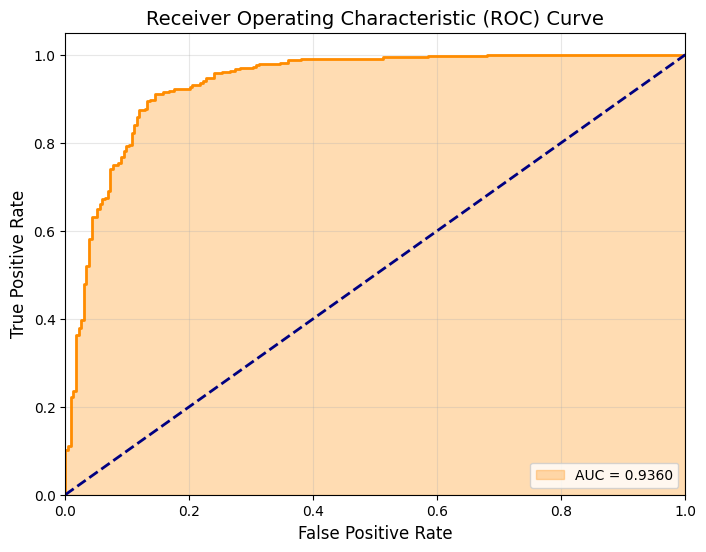

ROC AUC Score: 0.935952


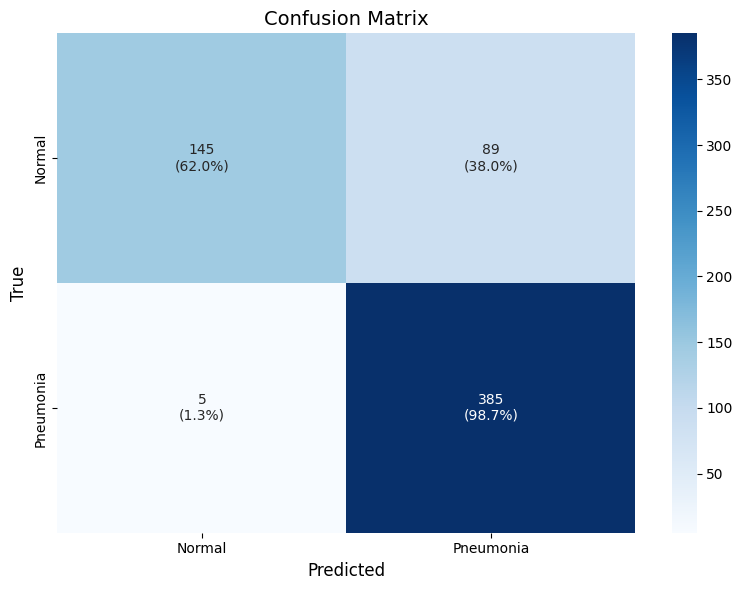

              precision    recall  f1-score   support

      Normal       0.97      0.62      0.76       234
   Pneumonia       0.81      0.99      0.89       390

    accuracy                           0.85       624
   macro avg       0.89      0.80      0.82       624
weighted avg       0.87      0.85      0.84       624



In [29]:
# Evaluate model with reduced verbosity
results = evaluate_model(model, test_images, test_labels, verbose=tf_verbosity)

# Add evaluation results to logger
logger.add_evaluation_results(results)

# Plot results
plot_roc_curve(results['roc']['fpr'], results['roc']['tpr'], results['roc']['auc'])
plot_confusion_matrix(results['confusion_matrix'])
print(results['classification_report'])

## Checkpointing

In [30]:
# Save all model information
logger.save(LOG_PATH)

# Save final model
model.save(FINAL_MODEL_PATH)
print(f"Model saved to {FINAL_MODEL_PATH}")

Run information saved to ../output/logs/densenet_169_augmented_info.json
Model saved to ../output/models/densenet_169_augmented_b96_lr0.001_dr0.3_pneumonia_model.keras
